In [1]:
import pandas as pd
import sqlite3
from sqlalchemy import create_engine
import matplotlib.pyplot as plt

conn   = sqlite3.connect('olist_database.db')
engine = create_engine('sqlite:///olist_database.db')

# Load payments table into database
payments = pd.read_csv('olist_order_payments_dataset.csv')
payments.to_sql('payments', conn, if_exists='replace', index=False)

print("Connected ✓")
print("payments table loaded ✓ —", len(payments), "rows")
print("\nPayment types available:")
print(payments['payment_type'].value_counts())

Connected ✓
payments table loaded ✓ — 103886 rows

Payment types available:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [2]:
distribution_query = '''
    SELECT
        payment_type,
        COUNT(*)                                        AS total_transactions,
        COUNT(DISTINCT order_id)                        AS unique_orders,
        ROUND(SUM(payment_value), 2)                    AS total_revenue,
        ROUND(AVG(payment_value), 2)                    AS avg_payment_value,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2)  AS transaction_share_pct,
        ROUND(SUM(payment_value) * 100.0 /
              SUM(SUM(payment_value)) OVER(), 2)        AS revenue_share_pct
    FROM payments
    WHERE payment_type != 'not_defined'
    GROUP BY payment_type
    ORDER BY total_transactions DESC
'''

distribution_df = pd.read_sql_query(distribution_query, conn)
print("=== Payment Method Distribution ===")
print(distribution_df.to_string(index=False))

=== Payment Method Distribution ===
payment_type  total_transactions  unique_orders  total_revenue  avg_payment_value  transaction_share_pct  revenue_share_pct
 credit_card               76795          76505    12542084.19             163.32                  73.92              78.34
      boleto               19784          19784     2869361.27             145.03                  19.04              17.92
     voucher                5775           3866      379436.87              65.70                   5.56               2.37
  debit_card                1529           1528      217989.79             142.57                   1.47               1.36


In [3]:
installment_query = '''
    SELECT
        payment_installments,
        COUNT(*)                            AS total_transactions,
        ROUND(AVG(payment_value), 2)        AS avg_payment_value,
        ROUND(SUM(payment_value), 2)        AS total_revenue,
        ROUND(COUNT(*) * 100.0 /
            SUM(COUNT(*)) OVER(), 2)        AS pct_of_cc_transactions
    FROM payments
    WHERE payment_type = 'credit_card'
    GROUP BY payment_installments
    ORDER BY payment_installments
'''

installments_df = pd.read_sql_query(installment_query, conn)
print("=== Credit Card Installment Breakdown ===")
print(installments_df.to_string(index=False))

=== Credit Card Installment Breakdown ===
 payment_installments  total_transactions  avg_payment_value  total_revenue  pct_of_cc_transactions
                    0                   2              94.31         188.63                    0.00
                    1               25455              95.87     2440445.43                   33.15
                    2               12413             127.23     1579283.03                   16.16
                    3               10461             142.54     1491103.80                   13.62
                    4                7098             163.98     1163907.61                    9.24
                    5                5239             183.47      961174.30                    6.82
                    6                3920             209.85      822611.81                    5.10
                    7                1626             187.67      305157.39                    2.12
                    8                4268             307.

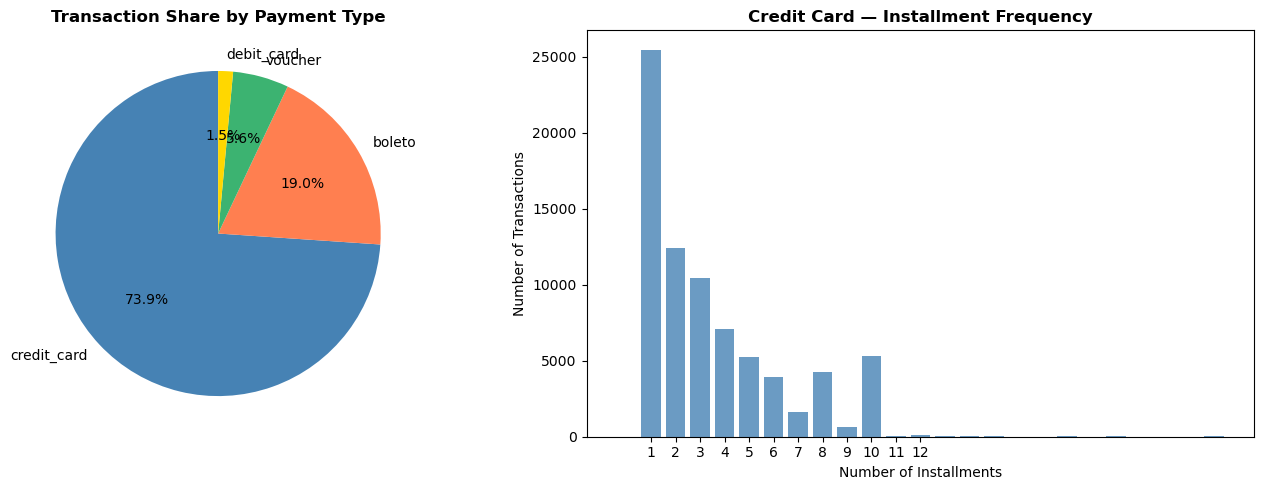


Key insight: 73.92% of transactions use credit card
Single installment (full payment) accounts for most CC transactions


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — transaction share
clean_dist = distribution_df[distribution_df['payment_type'] != 'not_defined']
axes[0].pie(clean_dist['total_transactions'],
            labels=clean_dist['payment_type'],
            autopct='%1.1f%%',
            colors=['steelblue','coral','mediumseagreen','gold'],
            startangle=90)
axes[0].set_title('Transaction Share by Payment Type', fontweight='bold')

# Chart 2 — installment distribution for credit card
axes[1].bar(installments_df['payment_installments'],
            installments_df['total_transactions'],
            color='steelblue', alpha=0.8)
axes[1].set_title('Credit Card — Installment Frequency', fontweight='bold')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Number of Transactions')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

print(f"\nKey insight: {clean_dist.iloc[0]['transaction_share_pct']}% of transactions use credit card")
print(f"Single installment (full payment) accounts for most CC transactions")

In [5]:
cancellation_query = '''
    SELECT
        p.payment_type,
        COUNT(DISTINCT o.order_id)                          AS total_orders,
        COUNT(DISTINCT CASE WHEN o.order_status = 'delivered'
              THEN o.order_id END)                          AS delivered_orders,
        COUNT(DISTINCT CASE WHEN o.order_status = 'canceled'
              THEN o.order_id END)                          AS canceled_orders,
        ROUND(
            COUNT(DISTINCT CASE WHEN o.order_status = 'canceled'
                  THEN o.order_id END) * 100.0 /
            COUNT(DISTINCT o.order_id), 2
        )                                                   AS cancellation_rate_pct,
        ROUND(
            COUNT(DISTINCT CASE WHEN o.order_status = 'delivered'
                  THEN o.order_id END) * 100.0 /
            COUNT(DISTINCT o.order_id), 2
        )                                                   AS delivery_success_rate_pct,
        ROUND(AVG(p.payment_value), 2)                      AS avg_payment_value
    FROM payments p
    JOIN orders o ON p.order_id = o.order_id
    WHERE p.payment_type != 'not_defined'
    GROUP BY p.payment_type
    ORDER BY cancellation_rate_pct DESC
'''

cancellation_df = pd.read_sql_query(cancellation_query, conn)
print("=== Cancellation Rate by Payment Type ===")
print(cancellation_df.to_string(index=False))

=== Cancellation Rate by Payment Type ===
payment_type  total_orders  delivered_orders  canceled_orders  cancellation_rate_pct  delivery_success_rate_pct  avg_payment_value
     voucher          3866              3679               94                   2.43                      95.16              65.70
 credit_card         76505             74304              444                   0.58                      97.12             163.32
      boleto         19784             19191               95                   0.48                      97.00             145.03
  debit_card          1528              1485                7                   0.46                      97.19             142.57


In [6]:
cc_cancel_query = '''
    SELECT
        p.payment_installments,
        COUNT(DISTINCT o.order_id)                          AS total_orders,
        COUNT(DISTINCT CASE WHEN o.order_status = 'canceled'
              THEN o.order_id END)                          AS canceled_orders,
        ROUND(
            COUNT(DISTINCT CASE WHEN o.order_status = 'canceled'
                  THEN o.order_id END) * 100.0 /
            COUNT(DISTINCT o.order_id), 2
        )                                                   AS cancellation_rate_pct,
        ROUND(AVG(p.payment_value), 2)                      AS avg_order_value
    FROM payments p
    JOIN orders o ON p.order_id = o.order_id
    WHERE p.payment_type = 'credit_card'
    GROUP BY p.payment_installments
    ORDER BY p.payment_installments
'''

cc_cancel_df = pd.read_sql_query(cc_cancel_query, conn)
print("=== Credit Card: Cancellation Rate by Installment Count ===")
print(cc_cancel_df.to_string(index=False))

=== Credit Card: Cancellation Rate by Installment Count ===
 payment_installments  total_orders  canceled_orders  cancellation_rate_pct  avg_order_value
                    0             2                0                   0.00            94.31
                    1         25407              142                   0.56            95.87
                    2         12389               60                   0.48           127.23
                    3         10443               69                   0.66           142.54
                    4          7088               42                   0.59           163.98
                    5          5234               30                   0.57           183.47
                    6          3916               22                   0.56           209.85
                    7          1623                6                   0.37           187.67
                    8          4253               29                   0.68           307.74
          

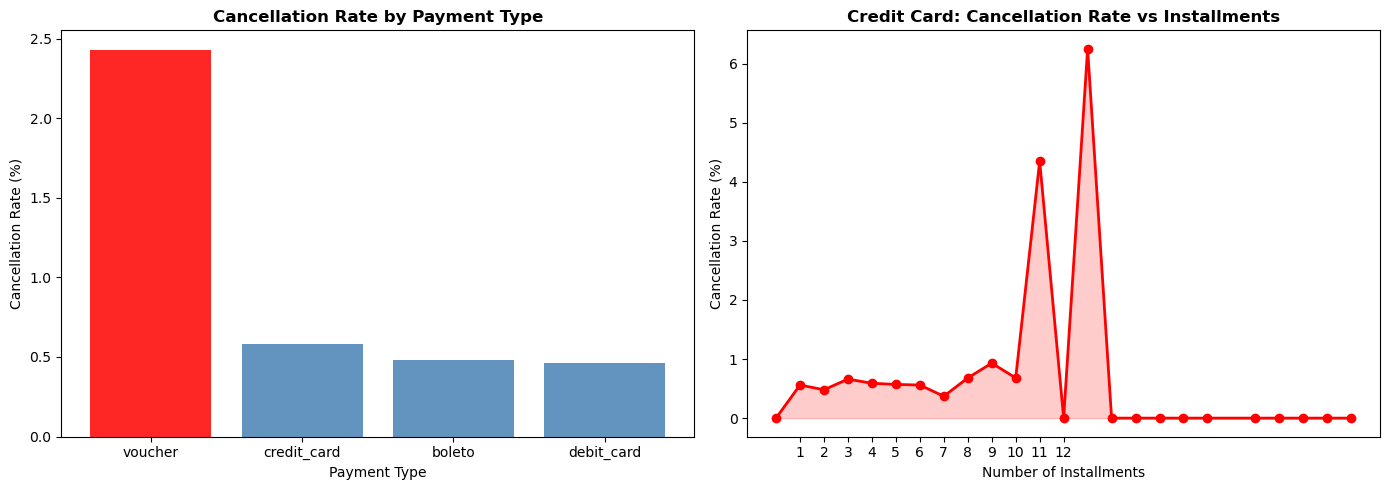

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1 — cancellation rate by payment type
colors = ['red' if x == cancellation_df['cancellation_rate_pct'].max()
          else 'steelblue' for x in cancellation_df['cancellation_rate_pct']]

axes[0].bar(cancellation_df['payment_type'],
            cancellation_df['cancellation_rate_pct'],
            color=colors, alpha=0.85)
axes[0].set_title('Cancellation Rate by Payment Type', fontweight='bold')
axes[0].set_xlabel('Payment Type')
axes[0].set_ylabel('Cancellation Rate (%)')

# Chart 2 — cancellation rate by installment count
axes[1].plot(cc_cancel_df['payment_installments'],
             cc_cancel_df['cancellation_rate_pct'],
             marker='o', color='red', linewidth=2)
axes[1].fill_between(cc_cancel_df['payment_installments'],
                     cc_cancel_df['cancellation_rate_pct'],
                     alpha=0.2, color='red')
axes[1].set_title('Credit Card: Cancellation Rate vs Installments', fontweight='bold')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [ ]:
full_breakdown_query = '''
    SELECT
        p.payment_type,
        o.order_status,
        COUNT(DISTINCT o.order_id)              AS order_count,
        ROUND(SUM(p.payment_value), 2)          AS total_value,
        ROUND(AVG(p.payment_value), 2)          AS avg_value
    FROM payments p
    JOIN orders o ON p.order_id = o.order_id
    WHERE p.payment_type IN ('credit_card', 'boleto', 'voucher', 'debit_card')
    GROUP BY p.payment_type, o.order_status
    ORDER BY p.payment_type, order_count DESC
'''

full_breakdown_df = pd.read_sql_query(full_breakdown_query, conn)
print("=== Full Payment × Status Breakdown ===")
print(full_breakdown_df.to_string(index=False))